# Aufgabe 3 - Tiefe Einblicke ins Institut: Reloaded

Den Code immer nachvollziehbar kommentieren! Bitte beachtet, dass das Notebook von Anfang bis Ende ohne Fehler durchlaufen muss und dass die requirements.txt Datei aktualisiert wird. 

In [ ]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F  
import torchvision.transforms as T
import torch.optim as optim
from torchvision.io import read_image
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import copy


## Teilaufgabe a): Trainings-, Test-und Validierungsdatenset

In [2]:
rooms = ['Flur', 'Labor', 'Professorenbuero', 'Teekueche']
training_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(1,16)]  # ["./pfad/zu/bildA.png","./pfad/zu/bildB.png",...]
validation_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(16, 20)] # ["./pfad/zu/bildZ.png","./pfad/zu/bildY.png",...]
test_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(20, 26)] # ["./pfad/zu/bildC.png","./pfad/zu/bildD.png",...]


## Teilaufgabe b): CNN definieren und implementieren

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)
        self.pool = nn.MaxPool2d(2)
        # self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        # self.pool = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(16, 64, kernel_size=3, stride=2, padding=1)
        self.pool = nn.MaxPool2d(2)
        
        # Am Ende haben wir 64 Filter auf einer Bildgröße von 8x8 Pixeln.
        # Das ergibt flachgedrückt: 64 * 8 * 8 = 4096 Features.
        self.fc1 = nn.Linear(4096, 128) # Feature-Kombination
        self.fc2 = nn.Linear(128, 4)    # Klassifikation in 4 Raumklassen
    def forward(self, x):
        x = F.relu(self.conv1(x))
        # x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = x.view(-1, x.size(1))
        
        return x

In [83]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # 224 x 224
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # -> 112 x 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # -> 56 x 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # -> 28 x 28

            # Mittelwert über die komplette Feature Map
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Teilaufgabe c): Training und Test mit CNN

Datenset-Klasse um mit Pytorch Bilder zu laden. 

Input sind: 
- Liste mit Pfaden zu Bildern
- Liste mit dazugehörigen Labels (numerisch darstellen!) 
- Transformation der Bilder


In [42]:
class ROBDataset(Dataset):
    def __init__(self, img_path_list, img_labels, transform=None):
        # Pfade zu den Bildern als list
        self.img_path_list = img_path_list
        
        # Dazugehörige Labels zu den Bildern als list
        self.img_labels = img_labels
        
        # Transformations der Bilder
        self.transform = transform

    def __len__(self):
        return len(self.img_path_list)

    def __getitem__(self, idx):
        # Bild laden
        img_path = self.img_path_list[idx]
        image = read_image(img_path)
        
        # Label laden
        label = self.img_labels[idx]
        
        # Transformieren
        if self.transform:
            image = self.transform(image)
            
        return image.float(), int(label)

Trainingsiteration über alle Bilder.

Inputs sind:
- Pytorch dataloader Object über das iteriert wird
- bool do_backprob Parameter um Backpropagation durchzuführen oder nicht

In [43]:
# Iterating over the entire data set once
def run_iteration(dataloader, do_backprob=True):
    global net, optimizer, criterion
    global device
    loss_iter = []
    acc_iter = []
    for batch_x, batch_y in dataloader:
        # To device
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        # zero the parameter gradients
        optimizer.zero_grad()
        
        # forward + backward + optimize
        y_predict = net(batch_x)
        loss = criterion(y_predict, batch_y)
        if do_backprob:
            loss.backward()
            optimizer.step()

        # statistics
        loss_iter.append(loss.detach().cpu().numpy())
        
        _, predicted = torch.max(torch.softmax(y_predict, dim=1),1)
        
        acc_iter.append(accuracy_score(batch_y.detach().cpu().numpy(), 
                                       predicted.detach().cpu().numpy()))
    
    return np.mean(loss_iter), np.mean(acc_iter)

Komplette Durchführung eines Trainings
Die Variablen y_train, y_val und y_test müssen noch gesetzt werden. Diese Listen beinhalten die entsprechenden Labels als numerische Darstellung.

Running on  cpu

Started Training
Epoch 1 from 100
	Train Loss	 1.3970712
	Train Acc.	 0.18333333333333332
	Val Loss	 1.3847088
	Val Acc.	 0.3125
Epoch 2 from 100
	Train Loss	 1.3854676
	Train Acc.	 0.26666666666666666
	Val Loss	 1.3811425
	Val Acc.	 0.3125
Epoch 3 from 100
	Train Loss	 1.3857399
	Train Acc.	 0.25
	Val Loss	 1.3792604
	Val Acc.	 0.25
Epoch 4 from 100
	Train Loss	 1.3830827
	Train Acc.	 0.21666666666666667
	Val Loss	 1.3747416
	Val Acc.	 0.3125
Epoch 5 from 100
	Train Loss	 1.3671824
	Train Acc.	 0.2833333333333333
	Val Loss	 1.363243
	Val Acc.	 0.3125
Epoch 6 from 100
	Train Loss	 1.3685625
	Train Acc.	 0.2833333333333333
	Val Loss	 1.3500409
	Val Acc.	 0.375
Epoch 7 from 100
	Train Loss	 1.3657056
	Train Acc.	 0.25
	Val Loss	 1.3373706
	Val Acc.	 0.3125
Epoch 8 from 100
	Train Loss	 1.3334534
	Train Acc.	 0.48333333333333334
	Val Loss	 1.3126519
	Val Acc.	 0.5
Epoch 9 from 100
	Train Loss	 1.3392754
	Train Acc.	 0.36666666666666664
	Val Loss	 1.2884984
	Val Acc.	 0.68

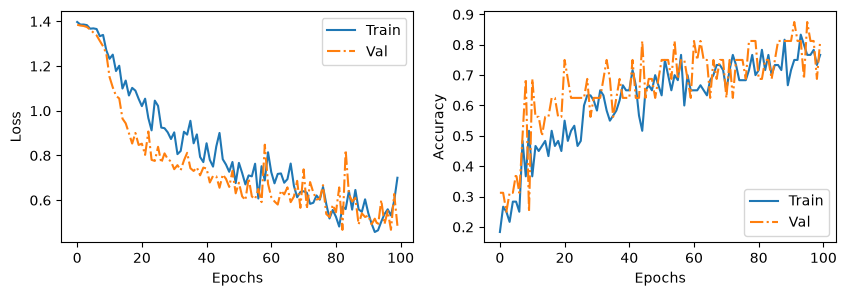

In [84]:
# Setting y_train, yval, y_test labels for the dataset
room_to_label = {'Flur': 0, 'Labor': 1, 'Professorenbuero': 2, 'Teekueche': 3}

y_train = [room_to_label[path.split('/')[1]] for path in training_path_list]
y_val = [room_to_label[path.split('/')[1]] for path in validation_path_list]
y_test = [room_to_label[path.split('/')[1]] for path in test_path_list]

# Training settings - bei Bedarf anpassbar
max_epoch = 100
batch_size = 4
lr = 0.001


# Transformations for dataloader
t_train = T.Compose([T.ToPILImage(),
                    T.ToTensor(),
                    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_val = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_test = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# Where to do calculations
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Running on ",device)

# Training Data, NOTE: y_train labels need to be set
dataset_train = ROBDataset(training_path_list, y_train, transform=t_train)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Validation Data, NOTE: y_val labels need to be set
dataset_val = ROBDataset(validation_path_list, y_val, transform=t_val)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# Test Data, NOTE: y_test labels need. to be set
dataset_test = ROBDataset(test_path_list, y_test,transform=t_test)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

# Network, optimizer and loss initialisation
net = Net()
net.to(device)
optimizer = optim.Adam(net.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Los geht's mit Training
print("\nStarted Training")
# Training loss and accuracy per epoch
train_loss_epoch = []
train_acc_epoch = []
# Validation loss and accuracy per epoch
val_loss_epoch = []
val_acc_epoch = []

for epoch in range(0,max_epoch):  # loop over the dataset multiple times
    print(f"Epoch {epoch+1} from {max_epoch}")
    
    ### TRAINING ###
    net.train()
    train_loss_iter, train_acc_iter = run_iteration(dataloader_train)

    # Logging loss and accuarcy of training iteration
    train_loss_epoch.append(train_loss_iter)
    train_acc_epoch.append(train_acc_iter)
    print("\tTrain Loss\t",train_loss_iter)
    print("\tTrain Acc.\t",train_acc_iter)
    
    ### VALIDATION ###
    with torch.no_grad():  # No gradient calculation
        net.eval()
        val_loss_iter, val_acc_iter = run_iteration(dataloader_val,do_backprob=False)

        # Logging loss and accuarcy of validation iteration
        val_loss_epoch.append(val_loss_iter)
        val_acc_epoch.append(val_acc_iter)
        print("\tVal Loss\t",val_loss_iter)
        print("\tVal Acc.\t",val_acc_iter)

# Plotting results
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,3))
ax[0].plot(train_loss_epoch,label="Train")
ax[0].plot(val_loss_epoch,label="Val",linestyle="-.")
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(train_acc_epoch,label="Train")
ax[1].plot(val_acc_epoch,label="Val",linestyle="-.")
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend()
plt.savefig("loss_augmentation.png",format="png",bbox_inches="tight")
plt.show()

In [85]:
#Vorhersagen (y_pred) über das trainierte Netz generieren
y_pred = []
with torch.no_grad():
    for batch_x, batch_y in dataloader_test:
        batch_x = batch_x.to(device)
        y_predict = net(batch_x)
        # Klasse mit der höchsten Wahrscheinlichkeit ermitteln
        _, predicted = torch.max(torch.softmax(y_predict, dim=1), 1)
        y_pred.extend(predicted.cpu().numpy())


In [86]:
# 2. Deine Metriken berechnen und ausgeben
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))


Accuracy : 0.7083333333333334
Precision: 0.6904761904761904
Recall   : 0.7083333333333334
F1       : 0.692948717948718


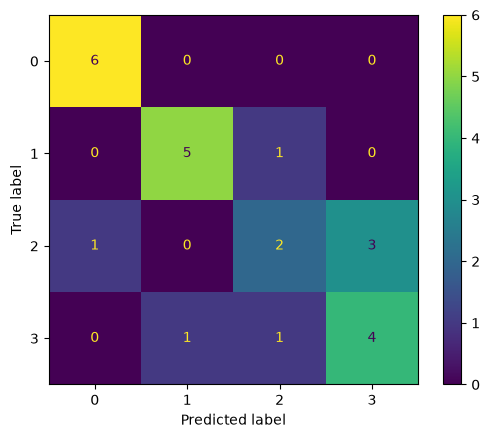

In [87]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

## Teilaufgabe d): Augmentierung

Running on  cpu

Started Training
Epoch 1 from 100
	Train Loss	 1.4027959
	Train Acc.	 0.25
	Val Loss	 1.3808442
	Val Acc.	 0.25
Epoch 2 from 100
	Train Loss	 1.3894763
	Train Acc.	 0.2
	Val Loss	 1.3722699
	Val Acc.	 0.3125
Epoch 3 from 100
	Train Loss	 1.3800603
	Train Acc.	 0.21666666666666667
	Val Loss	 1.3710358
	Val Acc.	 0.4375
Epoch 4 from 100
	Train Loss	 1.3760432
	Train Acc.	 0.31666666666666665
	Val Loss	 1.3624979
	Val Acc.	 0.375
Epoch 5 from 100
	Train Loss	 1.3859925
	Train Acc.	 0.2833333333333333
	Val Loss	 1.3500227
	Val Acc.	 0.25
Epoch 6 from 100
	Train Loss	 1.3634782
	Train Acc.	 0.26666666666666666
	Val Loss	 1.3410099
	Val Acc.	 0.3125
Epoch 7 from 100
	Train Loss	 1.3563565
	Train Acc.	 0.35
	Val Loss	 1.3279989
	Val Acc.	 0.25
Epoch 8 from 100
	Train Loss	 1.3359408
	Train Acc.	 0.2833333333333333
	Val Loss	 1.3115458
	Val Acc.	 0.3125
Epoch 9 from 100
	Train Loss	 1.3672278
	Train Acc.	 0.25
	Val Loss	 1.2855468
	Val Acc.	 0.5
Epoch 10 from 100
	Train Loss	 

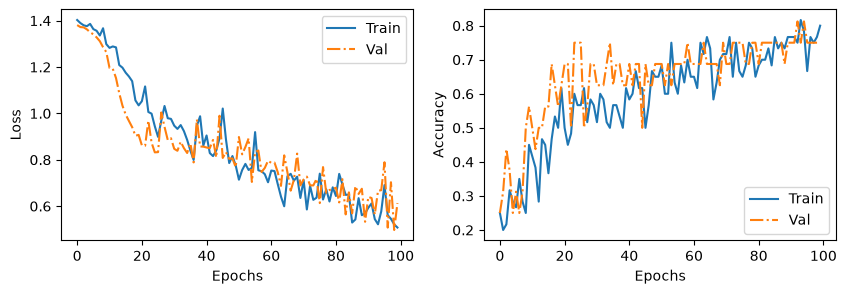

In [75]:
# Setting y_train, yval, y_test labels for the dataset
room_to_label = {'Flur': 0, 'Labor': 1, 'Professorenbuero': 2, 'Teekueche': 3}

y_train = [room_to_label[path.split('/')[1]] for path in training_path_list]
y_val = [room_to_label[path.split('/')[1]] for path in validation_path_list]
y_test = [room_to_label[path.split('/')[1]] for path in test_path_list]

# Training settings - bei Bedarf anpassbar
max_epoch = 100
batch_size = 4
lr = 0.001


# Transformations for dataloader
t_train = T.Compose([T.ToPILImage(),
                    T.ToTensor(),
                    T.RandomHorizontalFlip(p=0.5), # Zufälliges horizontales Spiegeln
                    T.RandomRotation(degrees=15),  # Zufällige Drehung um bis zu 15 Grad
                    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_val = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_test = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# Where to do calculations
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Running on ",device)

# Training Data, NOTE: y_train labels need to be set
dataset_train = ROBDataset(training_path_list, y_train, transform=t_train)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Validation Data, NOTE: y_val labels need to be set
dataset_val = ROBDataset(validation_path_list, y_val, transform=t_val)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# Test Data, NOTE: y_test labels need. to be set
dataset_test = ROBDataset(test_path_list, y_test,transform=t_test)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

# Network, optimizer and loss initialisation
net = Net()
net.to(device)
optimizer = optim.Adam(net.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Los geht's mit Training
print("\nStarted Training")
# Training loss and accuracy per epoch
train_loss_epoch = []
train_acc_epoch = []
# Validation loss and accuracy per epoch
val_loss_epoch = []
val_acc_epoch = []

for epoch in range(0,max_epoch):  # loop over the dataset multiple times
    print(f"Epoch {epoch+1} from {max_epoch}")
    
    ### TRAINING ###
    net.train()
    train_loss_iter, train_acc_iter = run_iteration(dataloader_train)

    # Logging loss and accuarcy of training iteration
    train_loss_epoch.append(train_loss_iter)
    train_acc_epoch.append(train_acc_iter)
    print("\tTrain Loss\t",train_loss_iter)
    print("\tTrain Acc.\t",train_acc_iter)
    
    ### VALIDATION ###
    with torch.no_grad():  # No gradient calculation
        net.eval()
        val_loss_iter, val_acc_iter = run_iteration(dataloader_val,do_backprob=False)

        # Logging loss and accuarcy of validation iteration
        val_loss_epoch.append(val_loss_iter)
        val_acc_epoch.append(val_acc_iter)
        print("\tVal Loss\t",val_loss_iter)
        print("\tVal Acc.\t",val_acc_iter)

# Plotting results
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,3))
ax[0].plot(train_loss_epoch,label="Train")
ax[0].plot(val_loss_epoch,label="Val",linestyle="-.")
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(train_acc_epoch,label="Train")
ax[1].plot(val_acc_epoch,label="Val",linestyle="-.")
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend()
plt.savefig("loss_augmentation.png",format="png",bbox_inches="tight")
plt.show()

In [76]:
#Vorhersagen (y_pred) über das trainierte Netz generieren
y_pred = []
with torch.no_grad():
    for batch_x, batch_y in dataloader_test:
        batch_x = batch_x.to(device)
        y_predict = net(batch_x)
        # Klasse mit der höchsten Wahrscheinlichkeit ermitteln
        _, predicted = torch.max(torch.softmax(y_predict, dim=1), 1)
        y_pred.extend(predicted.cpu().numpy())


In [77]:
# 2. Deine Metriken berechnen und ausgeben
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))


Accuracy : 0.6666666666666666
Precision: 0.6458333333333334
Recall   : 0.6666666666666666
F1       : 0.6279761904761905


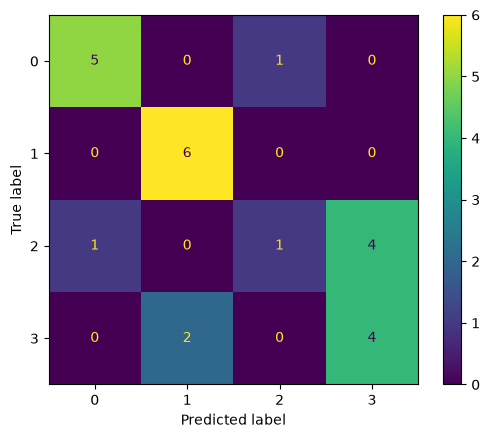

In [78]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

## Teilaufgabe e): Early Stopping

Running on  cpu

Started Training
Epoch 1 from 100
	Train Loss	 1.3978767
	Train Acc.	 0.26666666666666666
	Val Loss	 1.3859895
	Val Acc.	 0.25
Epoch 2 from 100
	Train Loss	 1.3781238
	Train Acc.	 0.2833333333333333
	Val Loss	 1.3766484
	Val Acc.	 0.25
Epoch 3 from 100
	Train Loss	 1.3851199
	Train Acc.	 0.3
	Val Loss	 1.3704096
	Val Acc.	 0.25
Epoch 4 from 100
	Train Loss	 1.3829943
	Train Acc.	 0.2
	Val Loss	 1.3637896
	Val Acc.	 0.5625
Epoch 5 from 100
	Train Loss	 1.3736001
	Train Acc.	 0.2833333333333333
	Val Loss	 1.3509902
	Val Acc.	 0.5
Epoch 6 from 100
	Train Loss	 1.3696352
	Train Acc.	 0.2833333333333333
	Val Loss	 1.3349605
	Val Acc.	 0.5625
Epoch 7 from 100
	Train Loss	 1.3463155
	Train Acc.	 0.38333333333333336
	Val Loss	 1.3132869
	Val Acc.	 0.5625
Epoch 8 from 100
	Train Loss	 1.299492
	Train Acc.	 0.4666666666666667
	Val Loss	 1.2284241
	Val Acc.	 0.625
Epoch 9 from 100
	Train Loss	 1.2388166
	Train Acc.	 0.48333333333333334
	Val Loss	 1.172279
	Val Acc.	 0.5625
Epoch 

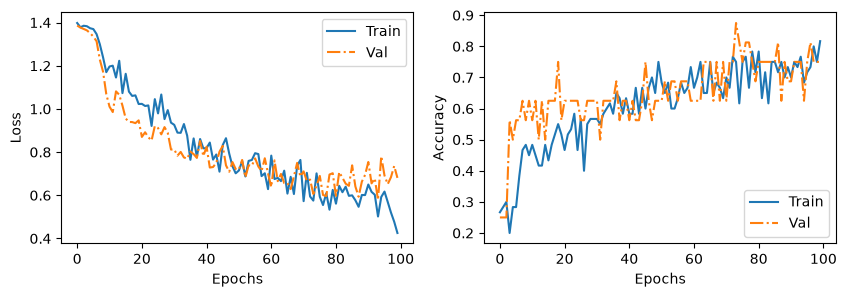

In [79]:
# Setting y_train, yval, y_test labels for the dataset
room_to_label = {'Flur': 0, 'Labor': 1, 'Professorenbuero': 2, 'Teekueche': 3}

y_train = [room_to_label[path.split('/')[1]] for path in training_path_list]
y_val = [room_to_label[path.split('/')[1]] for path in validation_path_list]
y_test = [room_to_label[path.split('/')[1]] for path in test_path_list]

# Training settings - bei Bedarf anpassbar
max_epoch = 100
batch_size = 4
lr = 0.001

# Early Stopping Einstellungen
patience = 10          # Wie viele Epochen das Netz ohne Verbesserung weiterlaufen darf
best_val_loss = np.inf # Startwert für den besten Fehler (wird kontinuierlich überschrieben)
patience_counter = 0   # Zähler, der hochzählt, wenn der Loss stagniert
best_model_wts = None  # Hierdrin parken wir das "Gehirn" des Modells im besten Zustand


# Transformations for dataloader
t_train = T.Compose([T.ToPILImage(),
                    T.ToTensor(),
                    T.RandomHorizontalFlip(p=0.5), # Zufälliges horizontales Spiegeln
                    T.RandomRotation(degrees=15),  # Zufällige Drehung um bis zu 15 Grad
                    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_val = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_test = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# Where to do calculations
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Running on ",device)

# Training Data, NOTE: y_train labels need to be set
dataset_train = ROBDataset(training_path_list, y_train, transform=t_train)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Validation Data, NOTE: y_val labels need to be set
dataset_val = ROBDataset(validation_path_list, y_val, transform=t_val)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# Test Data, NOTE: y_test labels need. to be set
dataset_test = ROBDataset(test_path_list, y_test,transform=t_test)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

# Network, optimizer and loss initialisation
net = Net()
net.to(device)
optimizer = optim.Adam(net.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Los geht's mit Training
print("\nStarted Training")
# Training loss and accuracy per epoch
train_loss_epoch = []
train_acc_epoch = []
# Validation loss and accuracy per epoch
val_loss_epoch = []
val_acc_epoch = []

for epoch in range(0,max_epoch):  # loop over the dataset multiple times
    print(f"Epoch {epoch+1} from {max_epoch}")
    
    ### TRAINING ###
    net.train()
    train_loss_iter, train_acc_iter = run_iteration(dataloader_train)

    # Logging loss and accuarcy of training iteration
    train_loss_epoch.append(train_loss_iter)
    train_acc_epoch.append(train_acc_iter)
    print("\tTrain Loss\t",train_loss_iter)
    print("\tTrain Acc.\t",train_acc_iter)
    
    ### VALIDATION ###
    with torch.no_grad():  # No gradient calculation
        net.eval()
        val_loss_iter, val_acc_iter = run_iteration(dataloader_val,do_backprob=False)

        # Logging loss and accuarcy of validation iteration
        val_loss_epoch.append(val_loss_iter)
        val_acc_epoch.append(val_acc_iter)
        print("\tVal Loss\t",val_loss_iter)
        print("\tVal Acc.\t",val_acc_iter)
    
    ### EARLY STOPPING CHECK ###
    if val_loss_iter < best_val_loss:
        best_val_loss = val_loss_iter
        # STATT COPY: Wir nutzen PyTorchs eigenen Klon-Befehl für Tensors
        best_model_wts = {k: v.clone() for k, v in net.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"\t--> Keine Verbesserung seit {patience_counter}/{patience} Epochen.")
        
    if patience_counter >= patience:
        print(f"\n[Early Stopping] Training vorzeitig abgebrochen in Epoche {epoch+1}!")
        break

if best_model_wts is not None:
    net.load_state_dict(best_model_wts)

# Plotting results
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,3))
ax[0].plot(train_loss_epoch,label="Train")
ax[0].plot(val_loss_epoch,label="Val",linestyle="-.")
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(train_acc_epoch,label="Train")
ax[1].plot(val_acc_epoch,label="Val",linestyle="-.")
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend()
plt.savefig("loss_augmentation.png",format="png",bbox_inches="tight")
plt.show()

In [80]:
#Vorhersagen (y_pred) über das trainierte Netz generieren
y_pred = []
with torch.no_grad():
    for batch_x, batch_y in dataloader_test:
        batch_x = batch_x.to(device)
        y_predict = net(batch_x)
        # Klasse mit der höchsten Wahrscheinlichkeit ermitteln
        _, predicted = torch.max(torch.softmax(y_predict, dim=1), 1)
        y_pred.extend(predicted.cpu().numpy())


In [81]:
# 2. Deine Metriken berechnen und ausgeben
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))


Accuracy : 0.8333333333333334
Precision: 0.8541666666666666
Recall   : 0.8333333333333334
F1       : 0.830952380952381


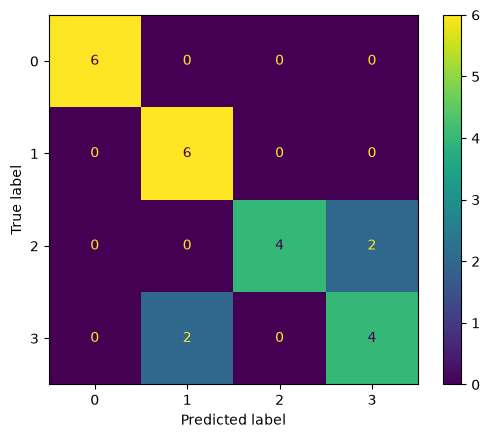

In [82]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()